## Practice: Basic Artificial Neural Networks
Credits: this notebook belongs to [Practical DL](https://docs.google.com/forms/d/e/1FAIpQLScvrVtuwrHSlxWqHnLt1V-_7h2eON_mlRR6MUb3xEe5x9LuoA/viewform?usp=sf_link) course by Yandex School of Data Analysis.

We will start working with neural networks on the practice session. Your homework will be to finish the implementation of the layers.

Our goal is simple, yet an actual implementation may take some time :). We are going to write an Artificial Neural Network (almost) from scratch. The software design was heavily inspired by [PyTorch](http://pytorch.org) which is the main framework of our course

Speaking about the homework (once again, it will be really similar to this seminar), it requires sending **multiple** files, please do not forget to include all the files when sending to TA. The list of files:
- This notebook
- modules.ipynb with all blocks implemented (except maybe `Conv2d` and `MaxPool2d` layers implementation which are part of 'advanced' version of this homework)

In [2]:
%matplotlib inline
from time import time, sleep
import numpy as np
import matplotlib.pyplot as plt
from IPython import display

In [3]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [4]:
%run /content/gdrive/MyDrive/Colab_Notebooks/modules_1.ipynb

# Framework

Implement everything in `modules.ipynb`. Read all the comments thoughtfully to ease the pain. Please try not to change the prototypes.

Do not forget, that each module should return **AND** store `output` and `gradInput`.

The typical assumption is that `module.backward` is always executed after `module.forward`,
so `output` is stored, this would be useful for `SoftMax`.

### Tech note
Prefer using `np.multiply`, `np.add`, `np.divide`, `np.subtract` instead of `*`,`+`,`/`,`-` for better memory handling.

Example: suppose you allocated a variable

```
a = np.zeros(...)
```
So, instead of
```
a = b + c  # will be reallocated, GC needed to free
```
You can use:
```
np.add(b,c,out = a) # puts result in `a`
```

In [ ]:
# (re-)load layers
%run modules.ipynb

# Toy example

Use this example to debug your code, start with logistic regression and then test other layers. You do not need to change anything here. This code is provided for you to test the layers. Also it is easy to use this code in MNIST task.

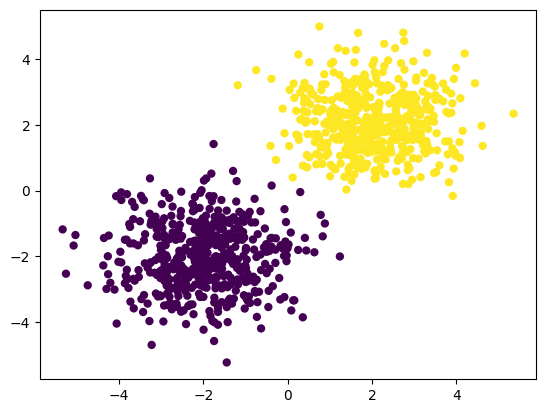

In [ ]:
# Generate some data
N = 500

X1 = np.random.randn(N,2) + np.array([2,2])
X2 = np.random.randn(N,2) + np.array([-2,-2])

Y = np.concatenate([np.ones(N),np.zeros(N)])[:,None]
Y = np.hstack([Y, 1-Y])

X = np.vstack([X1,X2])
plt.scatter(X[:,0],X[:,1], c = Y[:,0], edgecolors= 'none')

Define a **logistic regression** for debugging.

In [ ]:
net = Sequential()
net.add(Linear(2, 2))
net.add(LogSoftMax())

criterion = ClassNLLCriterion()

print(net)

# Test something like that then

# net = Sequential()
# net.add(Linear(2, 4))
# net.add(ReLU())
# net.add(Linear(4, 2))
# net.add(LogSoftMax())

Linear 2 -> 2
LogSoftMax



Start with batch_size = 1000 to make sure every step lowers the loss, then try stochastic version.

In [ ]:
# Iptimizer params
optimizer_config = {'learning_rate' : 1e-1, 'momentum': 0.9}
optimizer_state = {}

# Looping params
n_epoch = 20
batch_size = 128

In [5]:
# batch generator
def get_batches(dataset, batch_size):
    X, Y = dataset
    n_samples = X.shape[0]

    # Shuffle at the start of epoch
    indices = np.arange(n_samples)
    np.random.shuffle(indices)

    for start in range(0, n_samples, batch_size):
        end = min(start + batch_size, n_samples)

        batch_idx = indices[start:end]

        yield X[batch_idx], Y[batch_idx]

### Train

Basic training loop. Examine it.

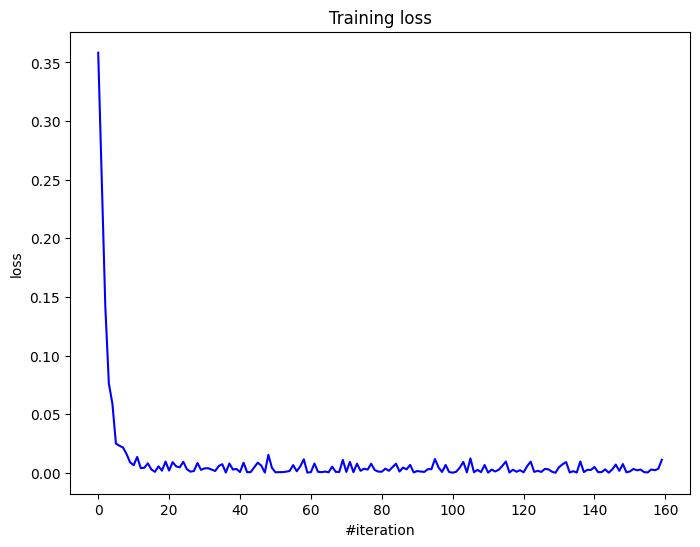

Current loss: 0.011235


In [ ]:
loss_history = []

for i in range(n_epoch):
    for x_batch, y_batch in get_batches((X, Y), batch_size):

        net.zeroGradParameters()

        # Forward
        predictions = net.forward(x_batch)
        loss = criterion.forward(predictions, y_batch)

        # Backward
        dp = criterion.backward(predictions, y_batch)
        net.backward(x_batch, dp)

        # Update weights
        sgd_momentum(net.getParameters(),
                     net.getGradParameters(),
                     optimizer_config,
                     optimizer_state)

        loss_history.append(loss)

    # Visualize
    display.clear_output(wait=True)
    plt.figure(figsize=(8, 6))

    plt.title("Training loss")
    plt.xlabel("#iteration")
    plt.ylabel("loss")
    plt.plot(loss_history, 'b')
    plt.show()

    print('Current loss: %f' % loss)

# Digit classification

We are using old good [MNIST](http://yann.lecun.com/exdb/mnist/) as our dataset. It can be downloaded with the following file.

In [ ]:
!wget https://raw.githubusercontent.com/girafe-ai/ml-course/23f_basic/homeworks/hw08_nn_from_scratch/mnist.py -nc

File ‘mnist.py’ already there; not retrieving.



In [6]:
import sys
sys.path.append('/content/mnist.py')

In [7]:
!wget -P ./data/MNIST/raw/ https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/train-images-idx3-ubyte.gz
!wget -P ./data/MNIST/raw/ https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/train-labels-idx1-ubyte.gz
!wget -P ./data/MNIST/raw/ https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/t10k-images-idx3-ubyte.gz
!wget -P ./data/MNIST/raw/ https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/t10k-labels-idx1-ubyte.gz

--2024-12-15 10:06:11--  https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/train-images-idx3-ubyte.gz
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion/train-images-idx3-ubyte.gz [following]
--2024-12-15 10:06:12--  https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion/train-images-idx3-ubyte.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 26421880 (25M) [application/octet-stream]
Saving to: ‘./data/MNIST/raw/train-images-idx3-ubyte.gz’

train-images-idx3-u 100%[===================>]  25.20M  

In [22]:
import os
import gzip

def load_dataset(flatten=False):
    def load_mnist_images(filename):
        # Проверяем, существует ли файл локально
        # if not os.path.exists(filename):
        #     raise FileNotFoundError(f"File not found: {filename}")
        # Открываем файл и загружаем изображения
        with gzip.open(filename, 'rb') as f:
            data = np.frombuffer(f.read(), np.uint8, offset=16)
        data = data.reshape(-1, 1, 28, 28)  # Reshape to monochrome 2D images
        return (data / np.float32(256)).squeeze()  # Normalize to [0, 1]

    def load_mnist_labels(filename):
        # Проверяем, существует ли файл локально
        # if not os.path.exists(filename):
        #     raise FileNotFoundError(f"File not found: {filename}")
        # Открываем файл и загружаем метки
        with gzip.open(filename, 'rb') as f:
            data = np.frombuffer(f.read(), np.uint8, offset=8)
        return data

    # Указываем локальные пути к файлам
    X_train = load_mnist_images('/content/data/MNIST/raw/train-images-idx3-ubyte.gz')
    y_train = load_mnist_labels('/content/data/MNIST/raw/train-labels-idx1-ubyte.gz')
    X_test = load_mnist_images('/content/data/MNIST/raw/t10k-images-idx3-ubyte.gz')
    y_test = load_mnist_labels('/content/data/MNIST/raw/t10k-labels-idx1-ubyte.gz')

    # Разделяем данные на обучение и валидацию
    X_train, X_val = X_train[:-10000], X_train[-10000:]
    y_train, y_val = y_train[:-10000], y_train[-10000:]

    # if flatten:
    #     X_train = X_train.reshape([-1, 28**2])
    #     X_val = X_val.reshape([-1, 28**2])
    #     X_test = X_test.reshape([-1, 28**2])

    return X_train, y_train, X_val, y_val, X_test, y_test


In [23]:
X_train, y_train, X_val, y_val, X_test, y_test = load_dataset()


In [ ]:
# import mnist
# X_train, y_train, X_val, y_val, X_test, y_test = mnist.load_dataset()
# # нормализация:
# X_train = np.array(X_train) / 255.0
# X_test = np.array(X_test) / 255.0

One-hot encode the labels first.

In [24]:
# Your code goes here. ################################################
def one_hot_encode(labels, num_classes=10):
    # Создаем пустой массив, который будет хранить one-hot вектора
    one_hot_labels = np.zeros((labels.shape[0], num_classes))

    # Для каждой метки устанавливаем значение 1 в соответствующий индекс
    one_hot_labels[np.arange(labels.shape[0]), labels] = 1
    return one_hot_labels
# Преобразуем метки в формат one-hot
y_train = one_hot_encode(y_train)
y_val = one_hot_encode(y_val)
y_test = one_hot_encode(y_test)

- **Compare** `ReLU`, `ELU`, `LeakyReLU`, `SoftPlus` activation functions.
You would better pick the best optimizer params for each of them, but it is overkill for now. Use an architecture of your choice for the comparison.
- **Try** inserting `BatchNormalization` (folowed by `ChannelwiseScaling`) between `Linear` module and activation functions.
- Plot the losses both from activation functions comparison and `BatchNormalization` comparison on one plot. Please find a scale (log?) when the lines are distinguishable, do not forget about naming the axes, the plot should be goodlooking.
- Plot the losses for two networks: one trained by momentum_sgd, another one trained by Adam. Which one performs better?
- Hint: good logloss for MNIST should be around 0.5.

In [ ]:
# Your code goes here. ################################################
# Простая модель с ReLU
model_ReLU = Sequential()
model_ReLU.add(Flatten())
model_ReLU.add(Linear(784, 100))
model_ReLU.add(ReLU())
model_ReLU.add(Linear(100, 10))
model_ReLU.add(LogSoftMax())
print('Простая модель с ReLU:')
print(model_ReLU)


Простая модель с ReLU:
Flatten
Linear 784 -> 100
ReLU
Linear 100 -> 10
LogSoftMax



In [ ]:
# Простая модель с ELU
model_ELU = Sequential()
model_ELU.add(Flatten())
model_ELU.add(Linear(784, 100))
model_ELU.add(ELU())
model_ELU.add(Linear(100, 10))
model_ELU.add(LogSoftMax())
print('Простая модель с ELU:')
print(model_ELU)

Простая модель с ELU:
Flatten
Linear 784 -> 100
ELU
Linear 100 -> 10
LogSoftMax



In [ ]:
# Простая модель с LeakyReLU
model_LeakyReLU = Sequential()
model_LeakyReLU.add(Flatten())
model_LeakyReLU.add(Linear(784, 100))
model_LeakyReLU.add(LeakyReLU())
model_LeakyReLU.add(Linear(100, 10))
model_LeakyReLU.add(LogSoftMax())
print('Простая модель с LeakyReLU:')
print(model_LeakyReLU)

Простая модель с LeakyReLU:
Flatten
Linear 784 -> 100
LeakyReLU
Linear 100 -> 10
LogSoftMax



In [ ]:
# Простая модель с SoftPlus
model_SoftPlus = Sequential()
model_SoftPlus.add(Flatten())
model_SoftPlus.add(Linear(784, 100))
model_SoftPlus.add(SoftPlus())
model_SoftPlus.add(Linear(100, 10))
model_SoftPlus.add(LogSoftMax())
print('Простая модель с SoftPlus:')
print(model_SoftPlus)

Простая модель с SoftPlus:
Flatten
Linear 784 -> 100
SoftPlus
Linear 100 -> 10
LogSoftMax



In [ ]:
# Простая модель с SoftPlus и BatchNormalisation:
model_SoftPlus_BatchN = Sequential()
model_SoftPlus_BatchN.add(Flatten())
model_SoftPlus_BatchN.add(Linear(784, 100))
model_SoftPlus_BatchN.add(BatchNormalization())
model_SoftPlus_BatchN.add(ChannelwiseScaling(100))
model_SoftPlus_BatchN.add(SoftPlus())
model_SoftPlus_BatchN.add(Linear(100, 10))
model_SoftPlus_BatchN.add(LogSoftMax())
print('Простая модель с SoftPlus и BatchNormalisation:')
print(model_SoftPlus)

Простая модель с SoftPlus и BatchNormalisation:
Flatten
Linear 784 -> 100
SoftPlus
Linear 100 -> 10
LogSoftMax



In [ ]:
from IPython import display
import time

def train_model_with_visualization(
    model, criterion, optimizer,
    X_train, y_train, X_test, y_test,
    batch_size, n_epoch, optimizer_config, optimizer_state
):

    train_loss_history = []
    test_loss_history = []
    test_accuracies_history = []
    start_time = time.time()
    for epoch in range(n_epoch):
        model.train()
        #model.zeroGradParameters()

        # === Обучение ===
        for x_batch, y_batch in get_batches((X_train, y_train), batch_size):
            # Прямой проход
            predictions = model.forward(x_batch)
            train_loss = criterion.forward(predictions, y_batch)

            # Обратный проход
            grad_output = criterion.backward(predictions, y_batch)
            model.backward(x_batch, grad_output)

            # Обновление весов
            optimizer(
                model.getParameters(),
                model.getGradParameters(),
                optimizer_config,
                optimizer_state
            )

            train_loss_history.append(train_loss)
            model.zeroGradParameters()

        # === Тестирование ===
        model.evaluate()
        predictions_test = model.forward(X_test)
        test_loss = criterion.forward(predictions_test, y_test)
        accuracy = np.mean(np.argmax(predictions_test, axis=1) == np.argmax(y_test, axis=1))
        test_loss_history.append(test_loss)
        test_accuracies_history.append(accuracy)

        # === Визуализация ===
        display.clear_output(wait=True)
        plt.figure(figsize=(10, 5))

        # График потерь
        plt.title(f"Epoch {epoch + 1}/{n_epoch} - Training Loss")
        plt.plot(train_loss_history, color="blue")
        plt.xlabel("Iteration")
        plt.ylabel("Loss")
        #plt.legend()
        plt.grid(True)
        plt.show()

        print(f"Epoch {epoch + 1}/{n_epoch}: Train Loss = {train_loss:.4f}, Test Loss = {test_loss:.4f}")
        end_time = time.time()  # Фиксируем конец
        elapsed_time = end_time - start_time  # Расчет времени обучения
        print(f"\nВремя обучения: {elapsed_time:.2f} секунд")
    return {
        'train_loss': train_loss_history,
        'test_loss': test_loss_history,
        'test_accuracy': test_accuracies_history
    }


In [25]:
criterion = ClassNLLCriterion()

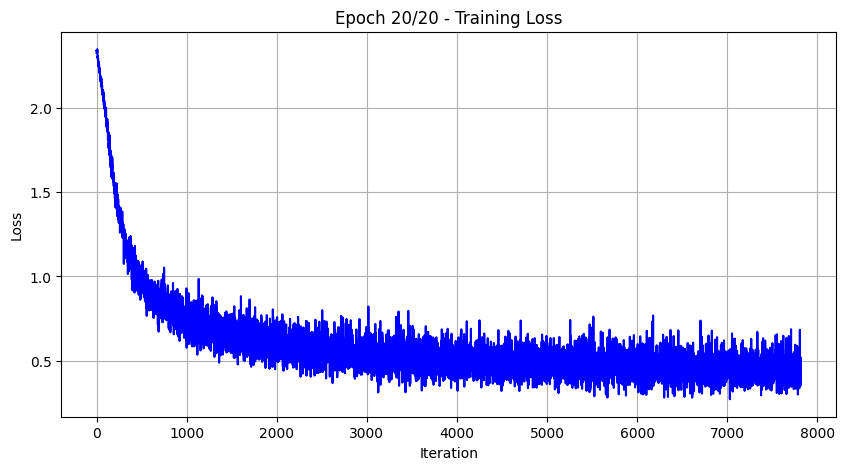

Epoch 20/20: Train Loss = 0.3801, Test Loss = 0.4812

Время обучения: 573.83 секунд
Простая модель с ReLU и SGD - 20 эпох


In [ ]:
history_Relu_SGD = train_model_with_visualization(
    model_ReLU,
    criterion,
    sgd_momentum,
    X_train,
    y_train,
    X_test,
    y_test,
    batch_size=128,
    n_epoch=20,
    optimizer_config={
        "learning_rate": 1e-3,
        'momentum': 0.9
    },
    optimizer_state={}
)
print('Простая модель с ReLU и SGD - 20 эпох')

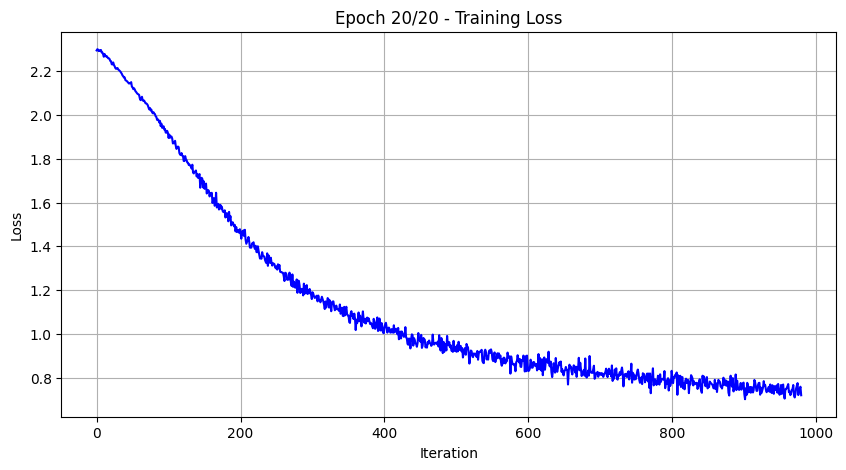

Epoch 20/20: Train Loss = 0.7207, Test Loss = 0.7534

Время обучения: 432.63 секунд
Простая модель с ReLU и SGD - 20 эпох батч 1024


In [ ]:
history_Relu_SGD_1024 = train_model_with_visualization(
    model_ReLU,
    criterion,
    sgd_momentum,
    X_train,
    y_train,
    X_test,
    y_test,
    batch_size=1024,
    n_epoch=20,
    optimizer_config={
        "learning_rate": 1e-3,
        'momentum': 0.9
    },
    optimizer_state={}
)
print('Простая модель с ReLU и SGD - 20 эпох батч 1024')

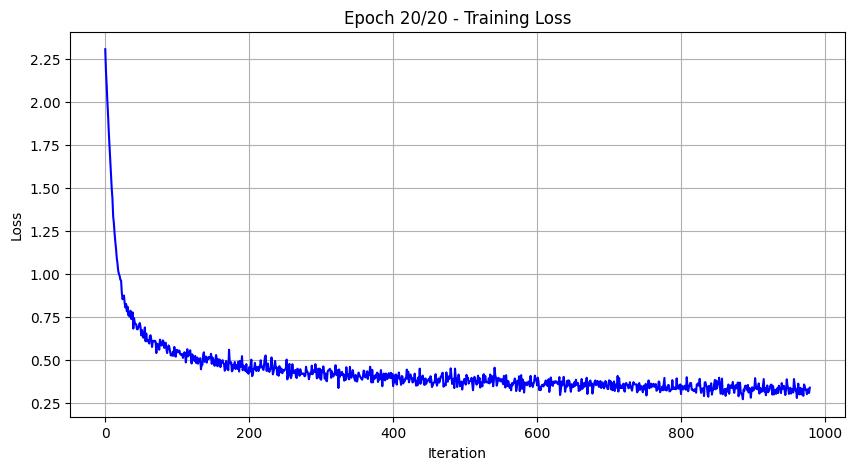

Epoch 20/20: Train Loss = 0.3378, Test Loss = 0.3925

Время обучения: 431.66 секунд
Простая модель с ReLU и Adam - 20 эпох


In [ ]:
history_Relu_Adam_20 = train_model_with_visualization(
    model_ReLU,
    criterion,
    adam_optimizer,
    X_train,
    y_train,
    X_test,
    y_test,
    batch_size=1024,
    n_epoch=20,
    optimizer_config={
        "learning_rate": 1e-3,
        "beta1": 0.9,
        "beta2": 0.999,
        "epsilon": 1e-8
    },
    optimizer_state={}
)
print('Простая модель с ReLU и Adam - 20 эпох')

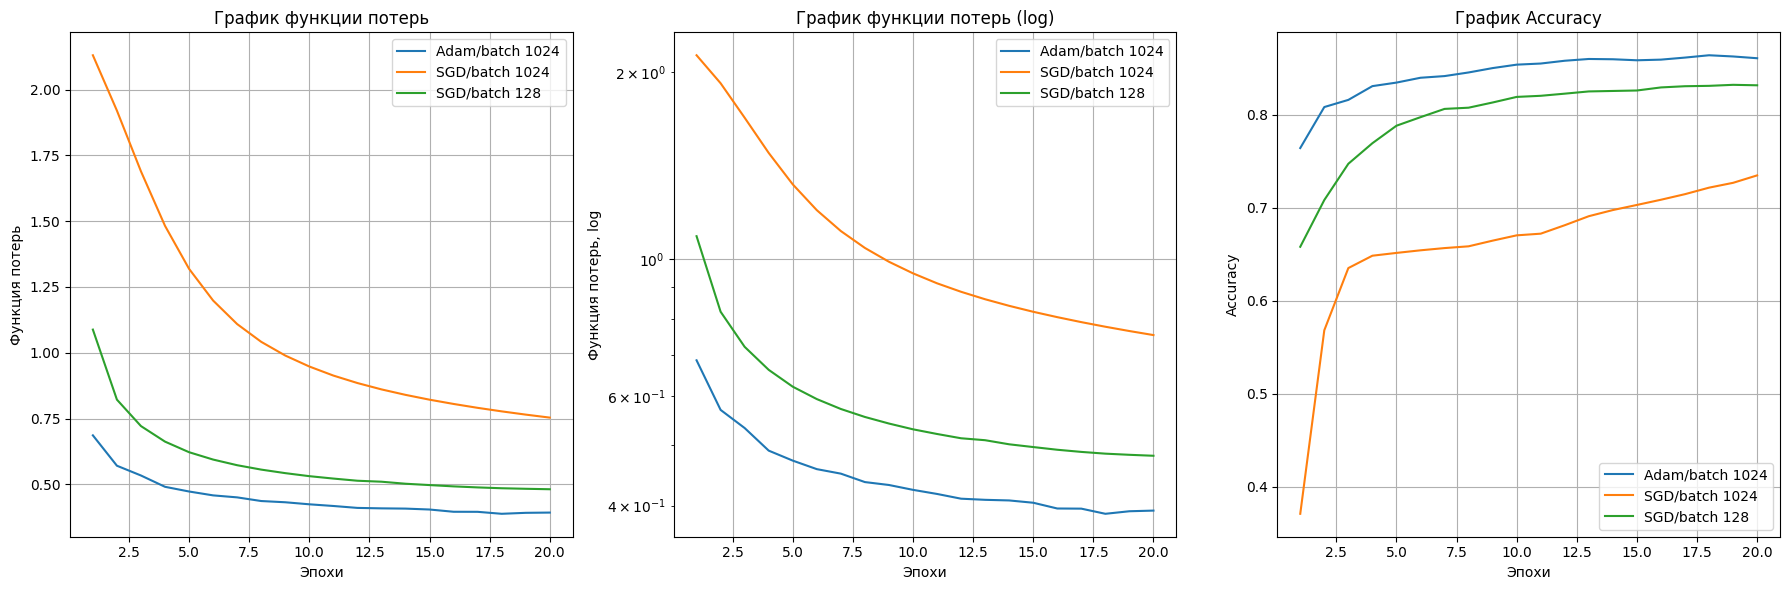

In [ ]:
histories = [history_Relu_Adam_20, history_Relu_SGD_1024, history_Relu_SGD]
model_names = ["Adam/batch 1024", "SGD/batch 1024", "SGD/batch 128"]

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
for i, history in enumerate(histories):
    plt.plot(range(1, len(history['test_loss']) + 1), history['test_loss'], label=f"{model_names[i]}")

plt.xlabel('Эпохи')
plt.ylabel('Функция потерь')
plt.title('График функции потерь')
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 2)
for i, history in enumerate(histories):
    plt.plot(range(1, len(history['test_loss']) + 1), history['test_loss'],
             label=f"{model_names[i]}")

plt.xlabel('Эпохи')
plt.ylabel('Функция потерь, log')
#plt.gca().tick_params(axis='y', labelrotation=90)
plt.title('График функции потерь (log)')
plt.grid(True)
plt.legend()
plt.yscale('log')

plt.subplot(1, 3, 3)
for i, history in enumerate(histories):
    plt.plot(range(1, len(history['test_accuracy']) + 1), history['test_accuracy'],
            label=f"{model_names[i]}")

plt.xlabel('Эпохи')
plt.ylabel('Accuracy')
plt.title('График Accuracy')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

При сравнении оптимизаторов Adam и SGD на примере простой модели с активтором ReLU установлено, что при использовании Adam функция ошибки снижается выстрее и достигает меньшего значения. Оптимизатор SGD достигает целевого значения ошибки 0,5 значительно позже (после 15 эпохи, тогда как при Adam - после 4 эпохи) и только при использовании маленького батча (128), что значительно замедляет процесс обучения. Таким образом, для сравнения функций активации будет использован оптимизатор Adam, батч 1024 и 10 эпох.   

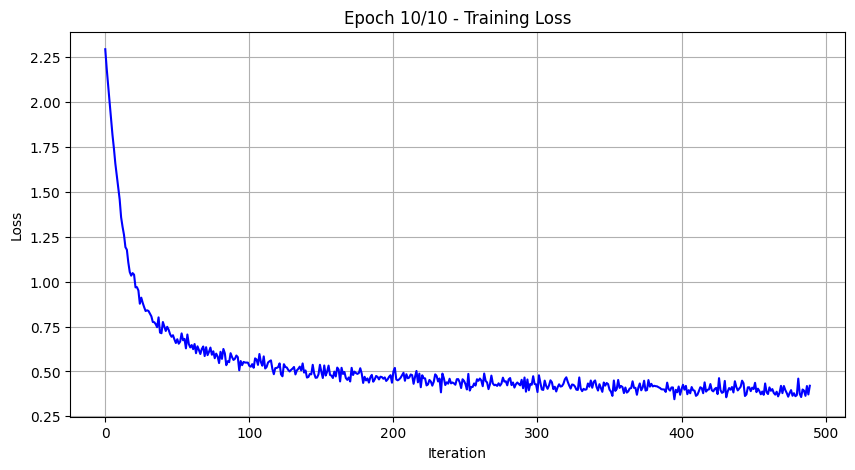

Epoch 10/10: Train Loss = 0.4202, Test Loss = 0.4299

Время обучения: 215.72 секунд
Простая модель с ReLU и Adam


In [ ]:
history_Relu_Adam = train_model_with_visualization(
    model_ReLU,
    criterion,
    adam_optimizer,
    X_train,
    y_train,
    X_test,
    y_test,
    batch_size=1024,
    n_epoch=10,
    optimizer_config={
        "learning_rate": 1e-3,
        "beta1": 0.9,
        "beta2": 0.999,
        "epsilon": 1e-8
    },
    optimizer_state={}
)
print('Простая модель с ReLU и Adam')

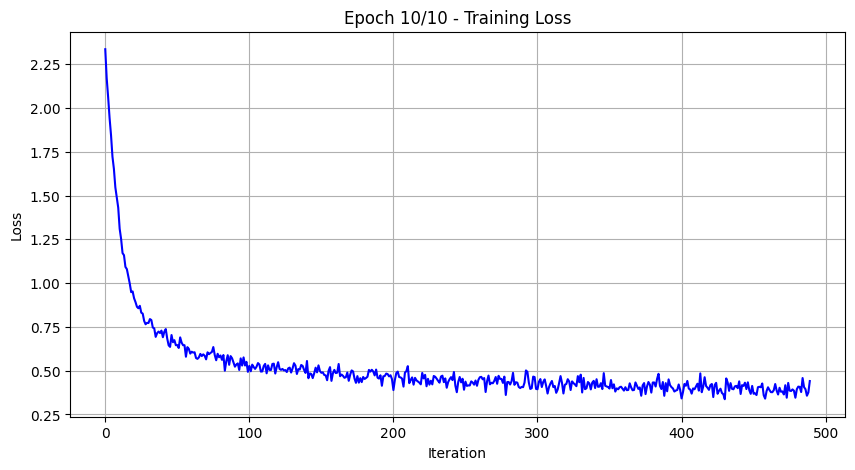

Epoch 10/10: Train Loss = 0.4409, Test Loss = 0.4348

Время обучения: 217.33 секунд
Простая модель с ELU и Adam


In [ ]:
history_ELU_Adam = train_model_with_visualization(
    model_ELU,
    criterion,
    adam_optimizer,
    X_train,
    y_train,
    X_test,
    y_test,
    batch_size=1024,
    n_epoch=10,
    optimizer_config={
        "learning_rate": 1e-3,
        "beta1": 0.9,
        "beta2": 0.999,
        "epsilon": 1e-8
    },
    optimizer_state={}
)
print('Простая модель с ELU и Adam')

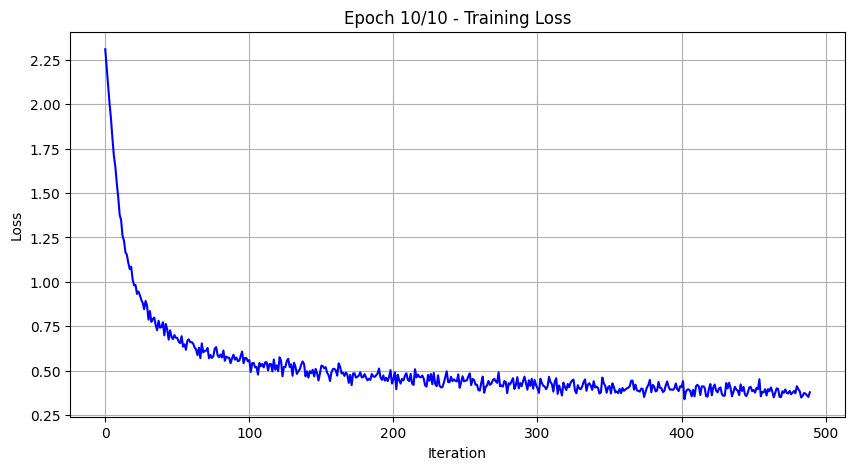

Epoch 10/10: Train Loss = 0.3789, Test Loss = 0.4181

Время обучения: 221.32 секунд
Простая модель с LeakyReLU и Adam


In [ ]:
history_LeakyReLU_Adam = train_model_with_visualization(
    model_LeakyReLU,
    criterion,
    adam_optimizer,
    X_train,
    y_train,
    X_test,
    y_test,
    batch_size=1024,
    n_epoch=10,
    optimizer_config={
        "learning_rate": 1e-3,
        "beta1": 0.9,
        "beta2": 0.999,
        "epsilon": 1e-8
    },
    optimizer_state={}
)
print('Простая модель с LeakyReLU и Adam')

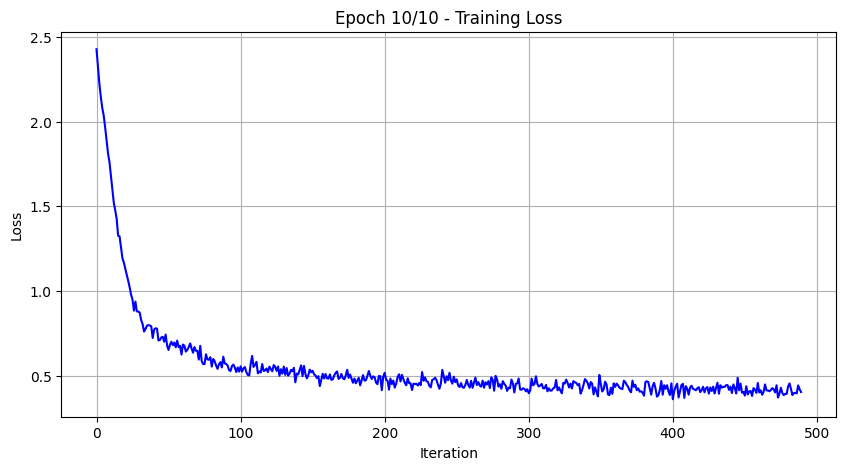

Epoch 10/10: Train Loss = 0.4027, Test Loss = 0.4507

Время обучения: 220.54 секунд
Простая модель с SoftPlus и Adam


In [ ]:
history_SoftPlus_Adam = train_model_with_visualization(
    model_SoftPlus,
    criterion,
    adam_optimizer,
    X_train,
    y_train,
    X_test,
    y_test,
    batch_size=1024,
    n_epoch=10,
    optimizer_config={
        "learning_rate": 1e-3,
        "beta1": 0.9,
        "beta2": 0.999,
        "epsilon": 1e-8
    },
    optimizer_state={}
)
print('Простая модель с SoftPlus и Adam')

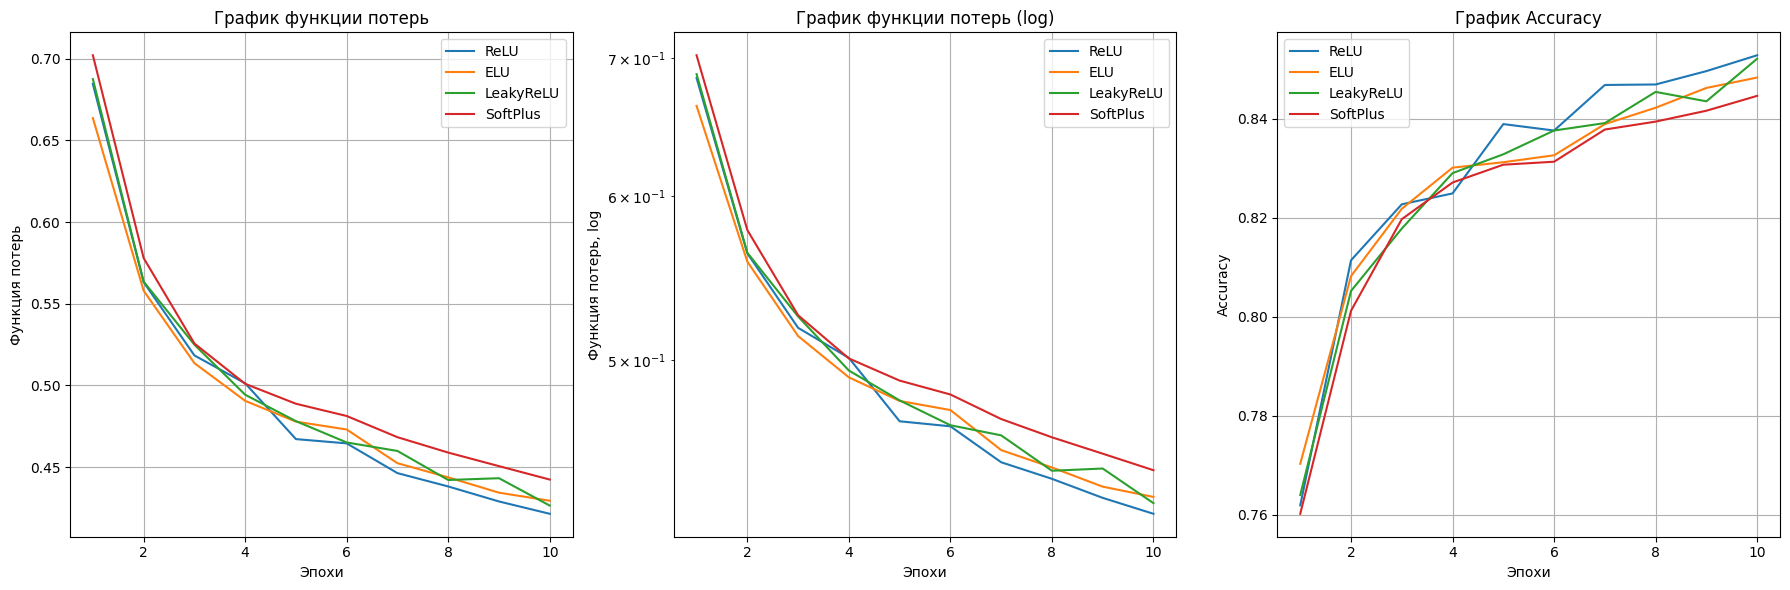

In [ ]:
histories = [history_Relu_Adam, history_ELU_Adam, history_LeakyReLU_Adam, history_SoftPlus_Adam]
model_names = ["ReLU", "ELU", "LeakyReLU", "SoftPlus"]

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
for i, history in enumerate(histories):
    plt.plot(range(1, len(history['test_loss']) + 1), history['test_loss'], label=f"{model_names[i]}")

plt.xlabel('Эпохи')
plt.ylabel('Функция потерь')
plt.title('График функции потерь')
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 2)
for i, history in enumerate(histories):
    plt.plot(range(1, len(history['test_loss']) + 1), history['test_loss'],
             label=f"{model_names[i]}")

plt.xlabel('Эпохи')
plt.ylabel('Функция потерь, log')
#plt.gca().tick_params(axis='y', labelrotation=90)
plt.title('График функции потерь (log)')
plt.grid(True)
plt.legend()
plt.yscale('log')

plt.subplot(1, 3, 3)
for i, history in enumerate(histories):
    plt.plot(range(1, len(history['test_accuracy']) + 1), history['test_accuracy'],
            label=f"{model_names[i]}")

plt.xlabel('Эпохи')
plt.ylabel('Accuracy')
plt.title('График Accuracy')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


Write your personal opinion on the activation functions, think about computation times too. Does `BatchNormalization` help?

In [ ]:
# Your answer goes here. ################################################

В целом все функции активации показали схожую эффективность, однако на данной простой модели самым эффективным оказался ReLU и по метрикам качества, и по времени обучения, а SoftPlus - наименее. Кривая функции потерь при использовании SoftPlus наиболее гладкая. Попробуем улучшить результаты SoftPlus при помощи регуляризации (BatchNormalization).

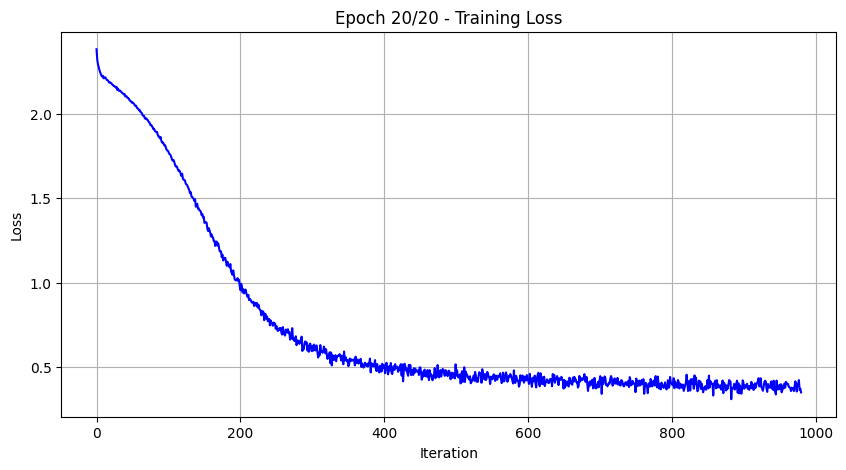

Epoch 20/20: Train Loss = 0.3492, Test Loss = 0.4506

Время обучения: 444.43 секунд
Простая модель с SoftPlus, Adam и BatchNormalization


In [ ]:
history_SoftPlus_Adam_BatchN = train_model_with_visualization(
    model_SoftPlus_BatchN,
    criterion,
    adam_optimizer,
    X_train,
    y_train,
    X_test,
    y_test,
    batch_size=1024,
    n_epoch=20,
    optimizer_config={
        "learning_rate": 1e-3,
        "beta1": 0.9,
        "beta2": 0.999,
        "epsilon": 1e-8
    },
    optimizer_state={}
)
print('Простая модель с SoftPlus, Adam и BatchNormalization')

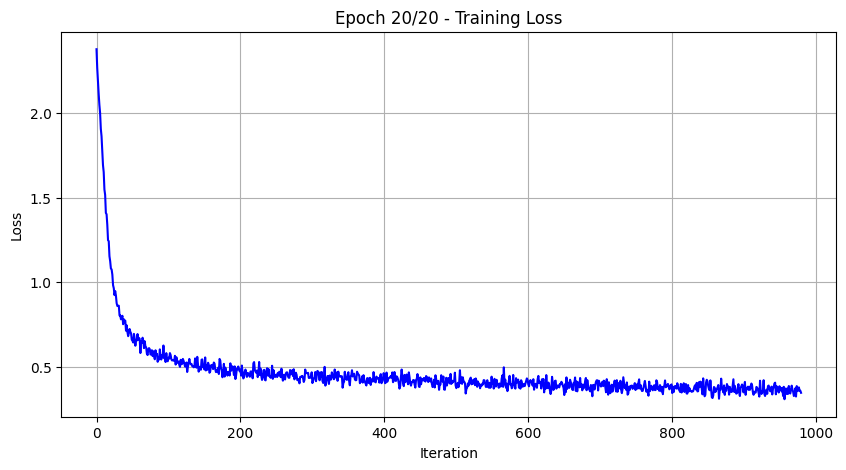

Epoch 20/20: Train Loss = 0.3464, Test Loss = 0.4082

Время обучения: 440.89 секунд
Простая модель с SoftPlus и Adam - 20 эпох


In [ ]:
history_SoftPlus_Adam_20 = train_model_with_visualization(
    model_SoftPlus,
    criterion,
    adam_optimizer,
    X_train,
    y_train,
    X_test,
    y_test,
    batch_size=1024,
    n_epoch=20,
    optimizer_config={
        "learning_rate": 1e-3,
        "beta1": 0.9,
        "beta2": 0.999,
        "epsilon": 1e-8
    },
    optimizer_state={}
)
print('Простая модель с SoftPlus и Adam - 20 эпох')

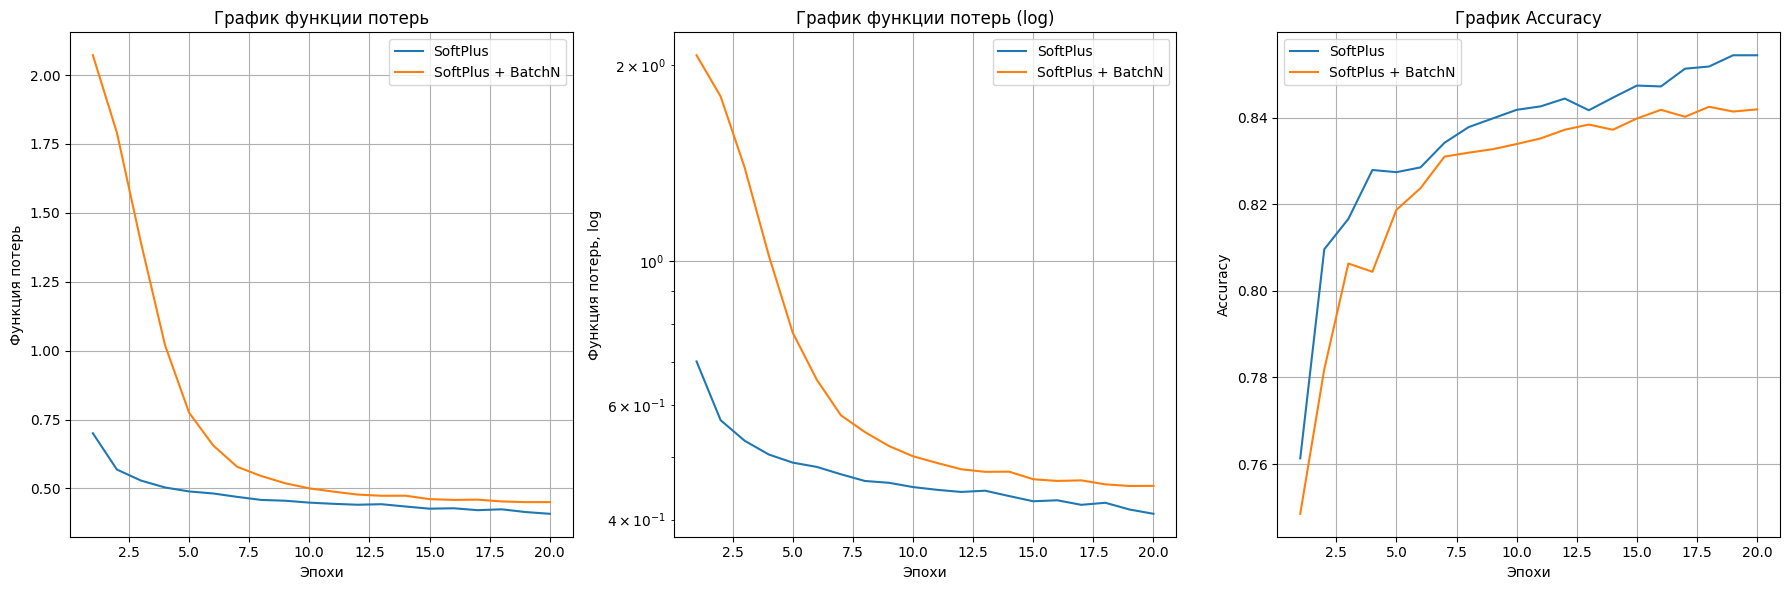

In [ ]:
histories = [history_SoftPlus_Adam_20, history_SoftPlus_Adam_BatchN]
model_names = ["SoftPlus", "SoftPlus + BatchN"]

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
for i, history in enumerate(histories):
    plt.plot(range(1, len(history['test_loss']) + 1), history['test_loss'], label=f"{model_names[i]}")

plt.xlabel('Эпохи')
plt.ylabel('Функция потерь')
plt.title('График функции потерь')
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 2)
for i, history in enumerate(histories):
    plt.plot(range(1, len(history['test_loss']) + 1), history['test_loss'],
             label=f"{model_names[i]}")

plt.xlabel('Эпохи')
plt.ylabel('Функция потерь, log')
#plt.gca().tick_params(axis='y', labelrotation=90)
plt.title('График функции потерь (log)')
plt.grid(True)
plt.legend()
plt.yscale('log')

plt.subplot(1, 3, 3)
for i, history in enumerate(histories):
    plt.plot(range(1, len(history['test_accuracy']) + 1), history['test_accuracy'],
            label=f"{model_names[i]}")

plt.xlabel('Эпохи')
plt.ylabel('Accuracy')
plt.title('График Accuracy')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


Изолированное применение BatchNormalization не улучшает метрики качества простой модели с актифацией SoftPlus.

Попробуем усложнить модель и сравним эффективность разных методов регуляризации.

In [ ]:
model_ReLU_complex = Sequential()
model_ReLU_complex.add(Flatten())
model_ReLU_complex.add(Linear(784, 512))
model_ReLU_complex.add(ReLU())
model_ReLU_complex.add(Linear(512, 256))
model_ReLU_complex.add(ReLU())
model_ReLU_complex.add(Linear(256, 128))
model_ReLU_complex.add(ReLU())
model_ReLU_complex.add(Linear(128, 10))
model_ReLU_complex.add(LogSoftMax())
print(model_ReLU_complex)



Flatten
Linear 784 -> 512
ReLU
Linear 512 -> 256
ReLU
Linear 256 -> 128
ReLU
Linear 128 -> 10
LogSoftMax



In [ ]:
model_ReLU_complex_Batch = Sequential()
model_ReLU_complex_Batch.add(Flatten())
model_ReLU_complex_Batch.add(Linear(784, 512))
model_ReLU_complex_Batch.add(BatchNormalization())
model_ReLU_complex_Batch.add(ChannelwiseScaling(512))
model_ReLU_complex_Batch.add(ReLU())
model_ReLU_complex_Batch.add(Linear(512, 256))
model_ReLU_complex_Batch.add(BatchNormalization())
model_ReLU_complex_Batch.add(ChannelwiseScaling(256))
model_ReLU_complex_Batch.add(ReLU())
model_ReLU_complex_Batch.add(Linear(256, 128))
model_ReLU_complex_Batch.add(BatchNormalization())
model_ReLU_complex_Batch.add(ChannelwiseScaling(128))
model_ReLU_complex_Batch.add(ReLU())
model_ReLU_complex_Batch.add(Linear(128, 10))
model_ReLU_complex_Batch.add(LogSoftMax())
print(model_ReLU_complex_Batch)

Flatten
Linear 784 -> 512
BatchNormalization
ChannelwiseScaling
ReLU
Linear 512 -> 256
BatchNormalization
ChannelwiseScaling
ReLU
Linear 256 -> 128
BatchNormalization
ChannelwiseScaling
ReLU
Linear 128 -> 10
LogSoftMax



In [ ]:
model_ReLU_complex_Batch_Drop = Sequential()
model_ReLU_complex_Batch_Drop.add(Flatten())
model_ReLU_complex_Batch_Drop.add(Linear(784, 512))
model_ReLU_complex_Batch_Drop.add(BatchNormalization())
model_ReLU_complex_Batch_Drop.add(ChannelwiseScaling(512))
model_ReLU_complex_Batch_Drop.add(ReLU())
model_ReLU_complex_Batch_Drop.add(Dropout(0.5))
model_ReLU_complex_Batch_Drop.add(Linear(512, 256))
model_ReLU_complex_Batch_Drop.add(BatchNormalization())
model_ReLU_complex_Batch_Drop.add(ChannelwiseScaling(256))
model_ReLU_complex_Batch_Drop.add(ReLU())
model_ReLU_complex_Batch_Drop.add(Dropout(0.5))
model_ReLU_complex_Batch_Drop.add(Linear(256, 128))
model_ReLU_complex_Batch_Drop.add(BatchNormalization())
model_ReLU_complex_Batch_Drop.add(ChannelwiseScaling(128))
model_ReLU_complex_Batch_Drop.add(ReLU())
model_ReLU_complex_Batch_Drop.add(Linear(128, 10))
model_ReLU_complex_Batch_Drop.add(LogSoftMax())
print(model_ReLU_complex_Batch_Drop)

Flatten
Linear 784 -> 512
BatchNormalization
ChannelwiseScaling
ReLU
Dropout
Linear 512 -> 256
BatchNormalization
ChannelwiseScaling
ReLU
Dropout
Linear 256 -> 128
BatchNormalization
ChannelwiseScaling
ReLU
Linear 128 -> 10
LogSoftMax



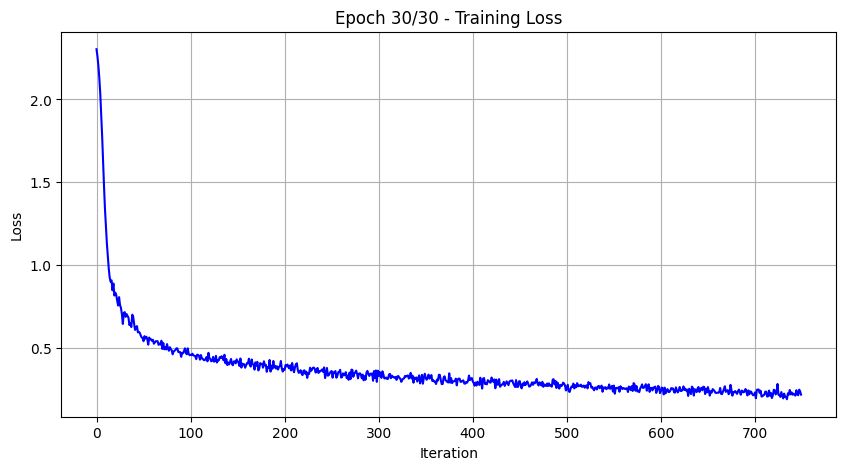

Epoch 30/30: Train Loss = 0.2155, Test Loss = 0.3364

Время обучения: 3862.11 секунд


In [ ]:
history_Relu_Adam_complex = train_model_with_visualization(
    model_ReLU_complex,
    criterion,
    adam_optimizer,
    X_train,
    y_train,
    X_test,
    y_test,
    batch_size=2048,
    n_epoch=30,
    optimizer_config={
        "learning_rate": 1e-3,
        "beta1": 0.9,
        "beta2": 0.999,
        "epsilon": 1e-8
    },
    optimizer_state={}
)

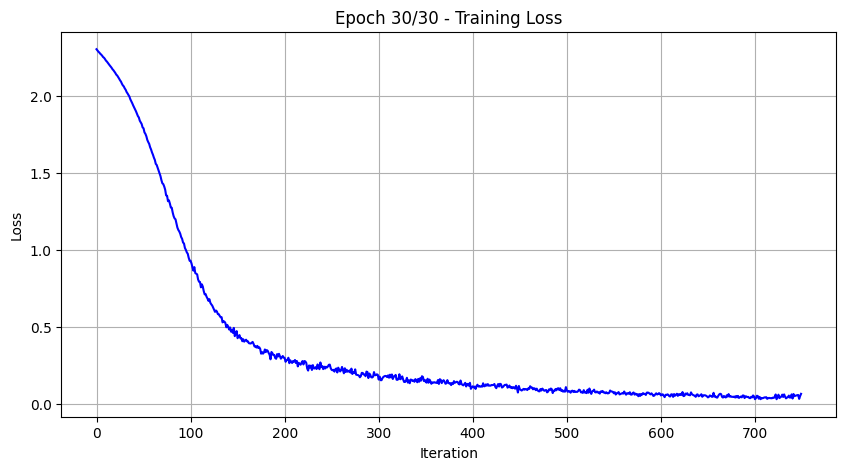

Epoch 30/30: Train Loss = 0.0650, Test Loss = 0.4615

Время обучения: 3980.83 секунд


In [ ]:
history_Relu_Adam_complex_Batch = train_model_with_visualization(
    model_ReLU_complex_Batch,
    criterion,
    adam_optimizer,
    X_train,
    y_train,
    X_test,
    y_test,
    batch_size=2048,
    n_epoch=30,
    optimizer_config={
        "learning_rate": 1e-3,
        "beta1": 0.9,
        "beta2": 0.999,
        "epsilon": 1e-8
    },
    optimizer_state={}
)

Видно, что применение BatchNormalization приводит к уменьшению колебаний модели при обучении

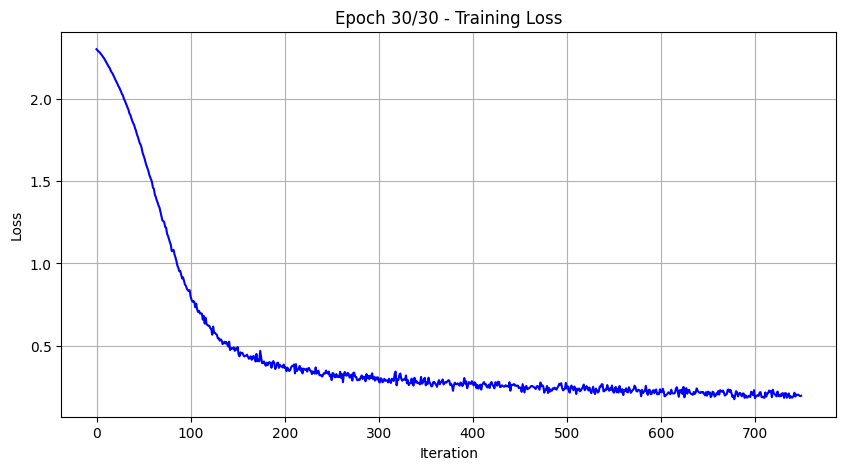

Epoch 30/30: Train Loss = 0.1958, Test Loss = 0.3098

Время обучения: 4054.32 секунд


In [ ]:
history_Relu_Adam_complex_Batch_Drop = train_model_with_visualization(
    model_ReLU_complex_Batch_Drop,
    criterion,
    adam_optimizer,
    X_train,
    y_train,
    X_test,
    y_test,
    batch_size=2048,
    n_epoch=30,
    optimizer_config={
        "learning_rate": 1e-3,
        "beta1": 0.9,
        "beta2": 0.999,
        "epsilon": 1e-8
    },
    optimizer_state={}
)


In [ ]:
model_ReLU_complex_Drop = Sequential()
model_ReLU_complex_Drop.add(Flatten())
model_ReLU_complex_Drop.add(Linear(784, 512))
model_ReLU_complex_Drop.add(ReLU())
model_ReLU_complex_Drop.add(Dropout(0.5))
model_ReLU_complex_Drop.add(Linear(512, 256))
model_ReLU_complex_Drop.add(ReLU())
model_ReLU_complex_Drop.add(Dropout(0.5))
model_ReLU_complex_Drop.add(Linear(256, 128))
model_ReLU_complex_Drop.add(ReLU())
model_ReLU_complex_Drop.add(Linear(128, 10))
model_ReLU_complex_Drop.add(LogSoftMax())
print(model_ReLU_complex_Drop)

Flatten
Linear 784 -> 512
ReLU
Dropout
Linear 512 -> 256
ReLU
Dropout
Linear 256 -> 128
ReLU
Linear 128 -> 10
LogSoftMax



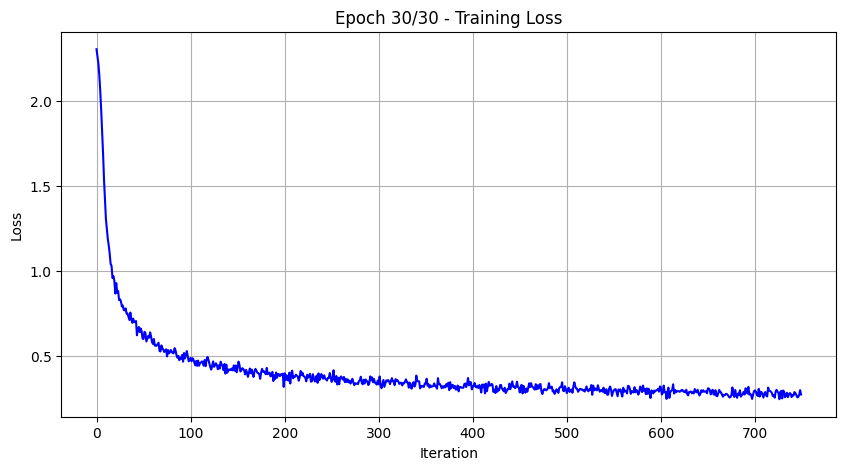

Epoch 30/30: Train Loss = 0.2727, Test Loss = 0.3228

Время обучения: 3979.37 секунд


In [ ]:
history_Relu_Adam_complex_Drop = train_model_with_visualization(
    model_ReLU_complex_Drop,
    criterion,
    adam_optimizer,
    X_train,
    y_train,
    X_test,
    y_test,
    batch_size=2048,
    n_epoch=30,
    optimizer_config={
        "learning_rate": 1e-3,
        "beta1": 0.9,
        "beta2": 0.999,
        "epsilon": 1e-8
    },
    optimizer_state={}
)

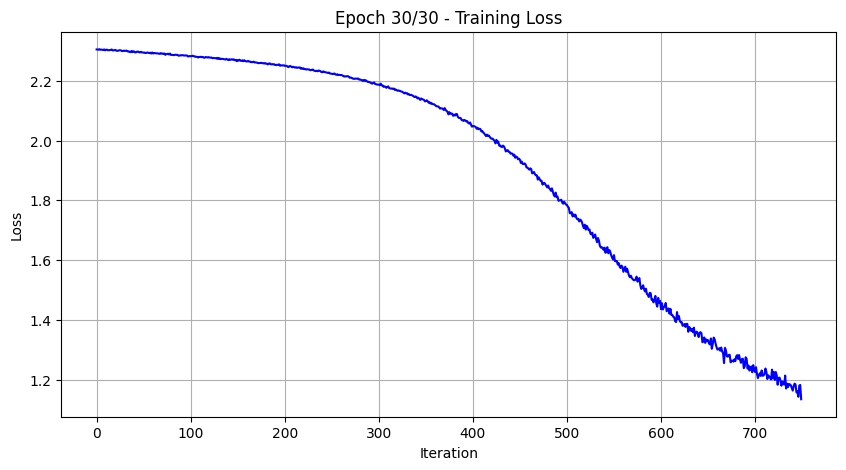

Epoch 30/30: Train Loss = 1.1344, Test Loss = 1.1710

Время обучения: 3985.45 секунд


In [ ]:
history_Relu_SGD_complex = train_model_with_visualization(
    model_ReLU_complex,
    criterion,
    sgd_momentum,
    X_train,
    y_train,
    X_test,
    y_test,
    batch_size=2048,
    n_epoch=30,
    optimizer_config={
        "learning_rate": 1e-3,
        'momentum': 0.9
    },
    optimizer_state={}
)

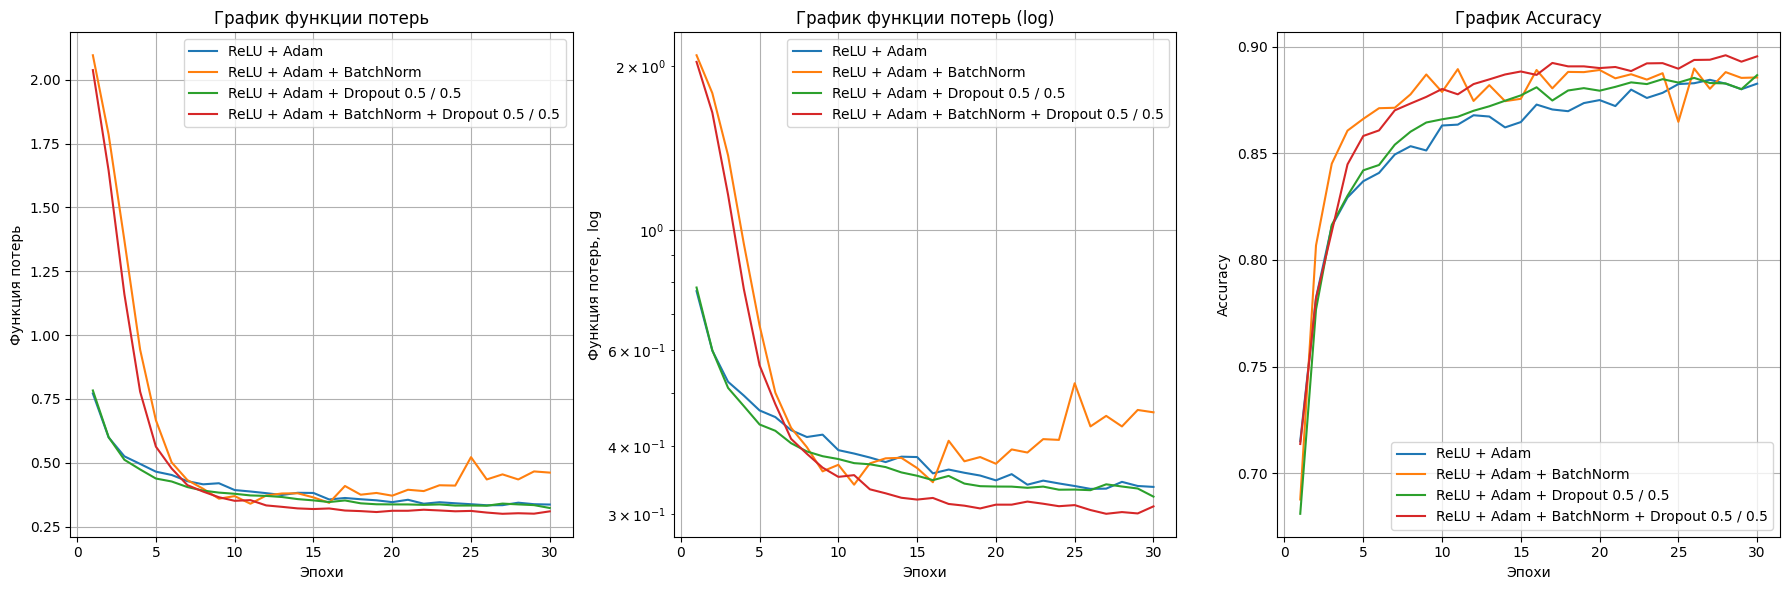

In [ ]:
histories = [history_Relu_Adam_complex, history_Relu_Adam_complex_Batch, history_Relu_Adam_complex_Drop, history_Relu_Adam_complex_Batch_Drop]#, history_Relu_SGD_complex, history_Relu_SGD_complex_Вatch]
model_names = ["ReLU + Adam", "ReLU + Adam + BatchNorm", "ReLU + Adam + Dropout 0.5 / 0.5", "ReLU + Adam + BatchNorm + Dropout 0.5 / 0.5"]#, "Relu + SGD", "Relu + SGD + Вatch"]

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
for i, history in enumerate(histories):
    plt.plot(range(1, len(history['test_loss']) + 1), history['test_loss'], label=f"{model_names[i]}")

plt.xlabel('Эпохи')
plt.ylabel('Функция потерь')
plt.title('График функции потерь')
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 2)
for i, history in enumerate(histories):
    plt.plot(range(1, len(history['test_loss']) + 1), history['test_loss'],
             label=f"{model_names[i]}")

plt.xlabel('Эпохи')
plt.ylabel('Функция потерь, log')
#plt.gca().tick_params(axis='y', labelrotation=90)
plt.title('График функции потерь (log)')
plt.grid(True)
plt.legend()
plt.yscale('log')

plt.subplot(1, 3, 3)
for i, history in enumerate(histories):
    plt.plot(range(1, len(history['test_accuracy']) + 1), history['test_accuracy'],
            label=f"{model_names[i]}")

plt.xlabel('Эпохи')
plt.ylabel('Accuracy')
plt.title('График Accuracy')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


На данной модели с данным датасетом наилучшие результаты показаны при использовании сочетания BatchNorm и Dropaut, изолированное использование BatchNorm приводило к переобучению, изолированный Dropout практичеки не отличался по метрикам качества от модели без дополнительных методов регуляризации, но проигрывал ей по времени обучения.

**Finally**, use all your knowledge to build a super cool model on this dataset. Use **dropout** to prevent overfitting, play with **learning rate decay**. You can use **data augmentation** such as rotations, translations to boost your score. Use your knowledge and imagination to train a model. Don't forget to call `training()` and `evaluate()` methods to set desired behaviour of `BatchNormalization` and `Dropout` layers.

In [36]:
# Your code goes here. ################################################
model_super_cool = Sequential()
model_super_cool.add(Flatten())
model_super_cool.add(Linear(784, 256))
model_super_cool.add(BatchNormalization())
model_super_cool.add(ChannelwiseScaling(256))
model_super_cool.add(ReLU())
model_super_cool.add(Dropout(0.5))
model_super_cool.add(Linear(256, 128))
model_super_cool.add(BatchNormalization())
model_super_cool.add(ChannelwiseScaling(128))
model_super_cool.add(ReLU())
model_super_cool.add(Dropout(0.5))
model_super_cool.add(Linear(128, 64))
model_super_cool.add(BatchNormalization())
model_super_cool.add(ChannelwiseScaling(64))
model_super_cool.add(ReLU())
model_super_cool.add(Linear(64, 10))
model_super_cool.add(LogSoftMax())
print ('Super cool model: \n')
print(model_super_cool)

Super cool model: 

Flatten
Linear 784 -> 256
BatchNormalization
ChannelwiseScaling
ReLU
Dropout
Linear 256 -> 128
BatchNormalization
ChannelwiseScaling
ReLU
Dropout
Linear 128 -> 64
BatchNormalization
ChannelwiseScaling
ReLU
Linear 64 -> 10
LogSoftMax



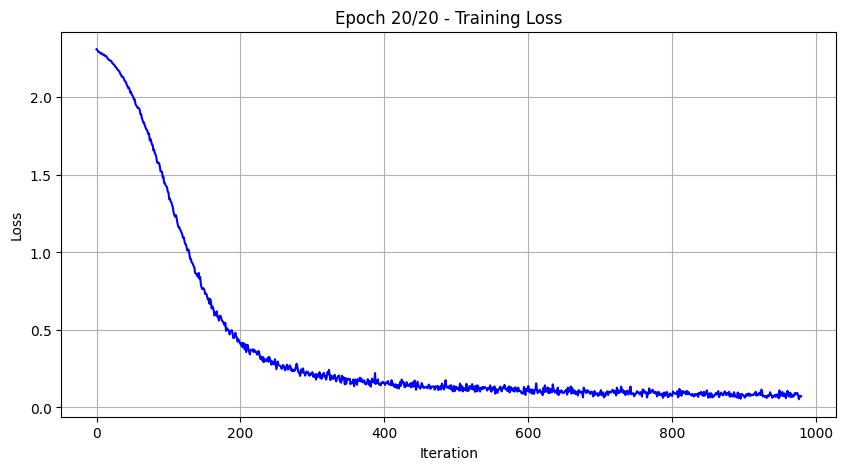

Epoch 20/20: Train Loss = 0.0721, Test Loss = 0.0756

Время обучения: 1364.18 секунд


In [ ]:
history_super_cool = train_model_with_visualization(
    model_super_cool,
    criterion,
    adam_optimizer,
    X_train,
    y_train,
    X_test,
    y_test,
    batch_size=1024,
    n_epoch=20,
    optimizer_config={
        "learning_rate": 1e-3,
        "beta1": 0.9,
        "beta2": 0.999,
        "epsilon": 1e-8
    },
    optimizer_state={}
)

In [ ]:
def train_model_with_visualization_decay(
    model, criterion, optimizer,
    X_train, y_train, X_test, y_test,
    batch_size, n_epoch, optimizer_config, optimizer_state,
    initial_lr, decay_rate
):

    train_loss_history = []
    test_loss_history = []
    test_accuracies_history = []

    optimizer_config['lr'] = initial_lr  # Initialize learning rate

    start_time = time.time()

    for epoch in range(n_epoch):
        model.train()
        #model.zeroGradParameters()

        # === Обучение ===
        for x_batch, y_batch in get_batches((X_train, y_train), batch_size):
            # Прямой проход
            predictions = model.forward(x_batch)
            train_loss = criterion.forward(predictions, y_batch)

            # Обратный проход
            grad_output = criterion.backward(predictions, y_batch)
            model.backward(x_batch, grad_output)

            # Обновление весов
            optimizer(
                model.getParameters(),
                model.getGradParameters(),
                optimizer_config,
                optimizer_state
            )

            train_loss_history.append(train_loss)
            model.zeroGradParameters()

        # === Тестирование ===
        model.evaluate()
        predictions_test = model.forward(X_test)
        test_loss = criterion.forward(predictions_test, y_test)
        accuracy = np.mean(np.argmax(predictions_test, axis=1) == np.argmax(y_test, axis=1))
        test_loss_history.append(test_loss)
        test_accuracies_history.append(accuracy)

        # === Learning Rate Decay ===
        optimizer_config['lr'] *= decay_rate

        # === Визуализация ===
        display.clear_output(wait=True)
        plt.figure(figsize=(10, 5))

        # График потерь
        plt.title(f"Epoch {epoch + 1}/{n_epoch} - Training Loss")
        plt.plot(train_loss_history, color="blue")
        plt.xlabel("Iteration")
        plt.ylabel("Loss")
        plt.grid(True)
        plt.show()

        print(f"Epoch {epoch + 1}/{n_epoch}: Train Loss = {train_loss:.4f}, Test Loss = {test_loss:.4f}, Accuracy = {accuracy:.4f}")

    end_time = time.time()  # Фиксируем конец
    elapsed_time = end_time - start_time  # Расчет времени обучения
    print(f"\nВремя обучения: {elapsed_time:.2f} секунд")

    return {
        'train_loss': train_loss_history,
        'test_loss': test_loss_history,
        'test_accuracy': test_accuracies_history
    }


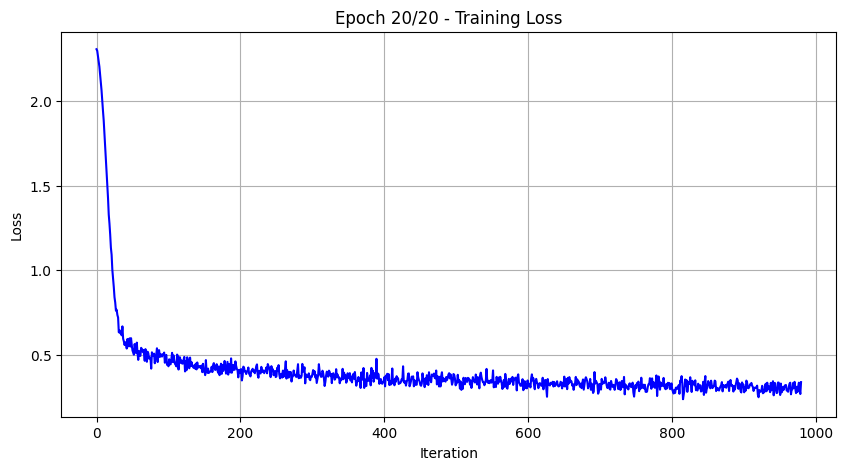

Epoch 20/20: Train Loss = 0.3410, Test Loss = 0.3411, Accuracy = 0.8802

Время обучения: 1311.64 секунд


In [ ]:
results = train_model_with_visualization_decay(
    model_super_cool,
    criterion,
    adam_optimizer,
    X_train,
    y_train,
    X_test,
    y_test,
    batch_size=1024,
    n_epoch=20,
    optimizer_config={
        "learning_rate": 0.01,
        "beta1": 0.9,
        "beta2": 0.999,
        "epsilon": 1e-8
    },
    optimizer_state={},
    initial_lr=0.01,  # начальная скорость обучения
    decay_rate=0.95   # уменьшение скорости на 5% каждую эпоху
)

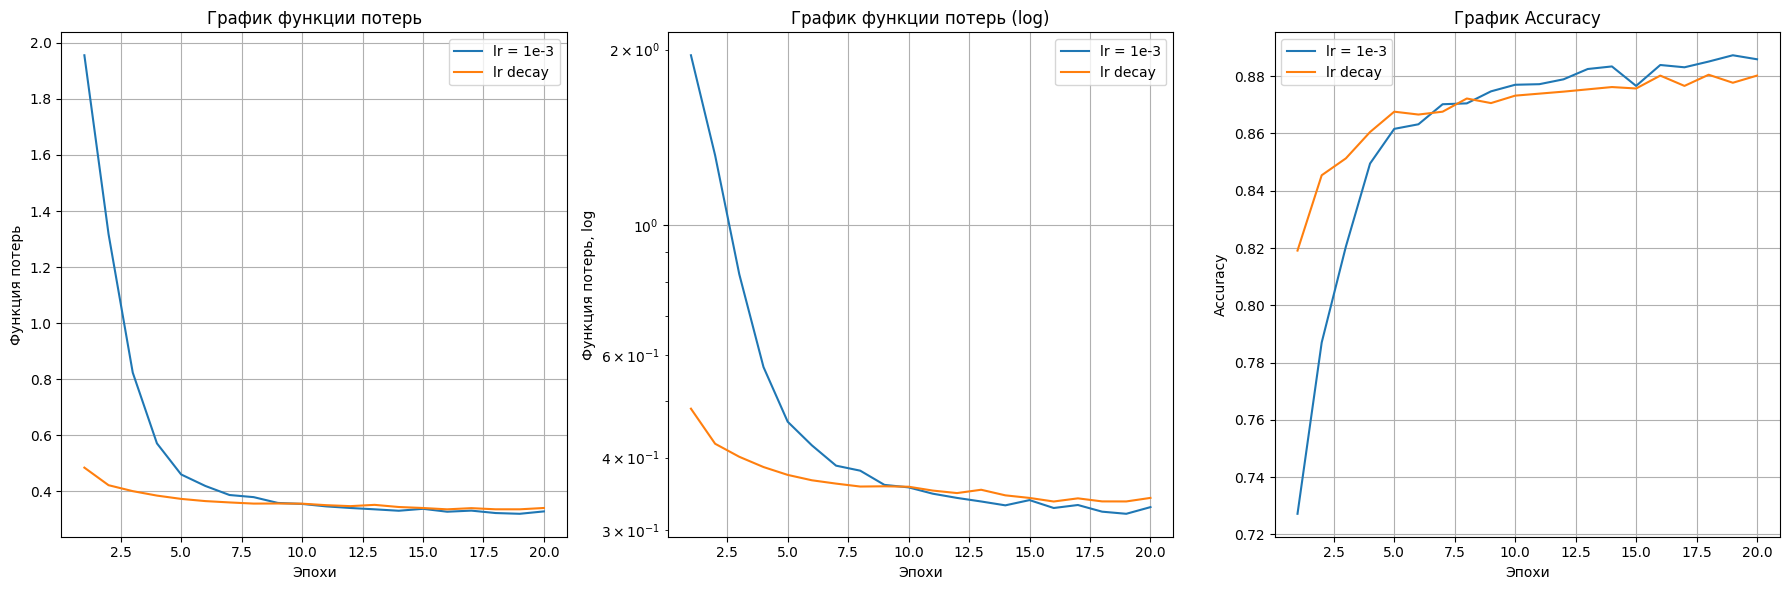

In [ ]:
histories = [history_super_cool, results]
model_names = ["lr = 1e-3", "lr decay"]

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
for i, history in enumerate(histories):
    plt.plot(range(1, len(history['test_loss']) + 1), history['test_loss'], label=f"{model_names[i]}")

plt.xlabel('Эпохи')
plt.ylabel('Функция потерь')
plt.title('График функции потерь')
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 2)
for i, history in enumerate(histories):
    plt.plot(range(1, len(history['test_loss']) + 1), history['test_loss'],
             label=f"{model_names[i]}")

plt.xlabel('Эпохи')
plt.ylabel('Функция потерь, log')
#plt.gca().tick_params(axis='y', labelrotation=90)
plt.title('График функции потерь (log)')
plt.grid(True)
plt.legend()
plt.yscale('log')

plt.subplot(1, 3, 3)
for i, history in enumerate(histories):
    plt.plot(range(1, len(history['test_accuracy']) + 1), history['test_accuracy'],
            label=f"{model_names[i]}")

plt.xlabel('Эпохи')
plt.ylabel('Accuracy')
plt.title('График Accuracy')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

Print here your accuracy on test set. It should be around 90%.

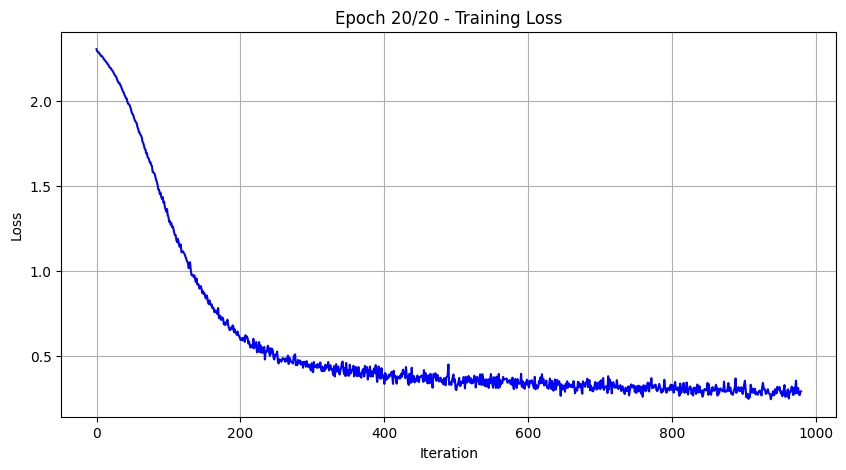

Epoch 20/20: Train Loss = 0.2903, Validation Loss = 0.3015
Validation Accuracy: 0.8901
Test Loss = 0.3236, Test Accuracy = 0.8851

Время обучения: 1337.47 секунд


In [37]:
train_loss_history = []
val_loss_history = []
test_loss_history = []
test_accuracies_history = []
start_time = time.time()

model = model_super_cool
criterion = ClassNLLCriterion()
optimizer = adam_optimizer
n_epoch = 20
batch_size = 1024

optimizer_config = {
    "learning_rate": 1e-3,
    "beta1": 0.9,
    "beta2": 0.999,
    "epsilon": 1e-8
}
optimizer_state = {}

for epoch in range(n_epoch):
    model.train()

    # === Обучение ===
    for x_batch, y_batch in get_batches((X_train, y_train), batch_size):
        # Прямой проход
        predictions = model.forward(x_batch)
        train_loss = criterion.forward(predictions, y_batch)

        # Обратный проход
        grad_output = criterion.backward(predictions, y_batch)
        model.backward(x_batch, grad_output)

        # Обновление весов
        optimizer(
            model.getParameters(),
            model.getGradParameters(),
            optimizer_config,
            optimizer_state,
        )

        train_loss_history.append(train_loss)
        model.zeroGradParameters()

    # === Валидация ===
    model.evaluate()
    predictions_val = model.forward(X_val)
    val_loss = criterion.forward(predictions_val, y_val)
    val_accuracy = np.mean(np.argmax(predictions_val, axis=1) == np.argmax(y_val, axis=1))
    val_loss_history.append(val_loss)

    # === Тестирование ===
    predictions_test = model.forward(X_test)
    test_loss = criterion.forward(predictions_test, y_test)
    test_accuracy = np.mean(np.argmax(predictions_test, axis=1) == np.argmax(y_test, axis=1))
    test_loss_history.append(test_loss)
    test_accuracies_history.append(test_accuracy)

    # === Визуализация ===
    display.clear_output(wait=True)
    plt.figure(figsize=(10, 5))

    # График потерь
    plt.title(f"Epoch {epoch + 1}/{n_epoch} - Training Loss")
    plt.plot(train_loss_history, color="blue")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()

    print(f"Epoch {epoch + 1}/{n_epoch}: Train Loss = {train_loss:.4f}, Validation Loss = {val_loss:.4f}")
    print(f"Validation Accuracy: {val_accuracy:.4f}")
    print(f"Test Loss = {test_loss:.4f}, Test Accuracy = {test_accuracy:.4f}")

    end_time = time.time()  # Фиксируем конец
    elapsed_time = end_time - start_time  # Расчет времени обучения
    print(f"\nВремя обучения: {elapsed_time:.2f} секунд")

result = {
    'train_loss': train_loss_history,
    'val_loss': val_loss_history,
    'test_loss': test_loss_history,
    'test_accuracy': test_accuracies_history
}


In [ ]:
# Your answer goes here. ################################################

Применение Learning Rate Decay приводит к более быстрому и плавному снижению функции потерь, однако на метрики качетсва не оказывает позитивного влияния. Использование постоянного Learning Rate = 1e-3 позволило достичь  показателя accuracy на тестовой группе 0.89.

### Comparing with PyTorch implementation
The last (and maybe the easiest step after compared to the previous tasks: build a network with the same architecture as above now with PyTorch.

You can refer to the `week0_09` or `Lab3_part2` notebooks for hints.

__Good Luck!__

In [38]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=1024, shuffle=False)

In [39]:
# Your beautiful code here.

class MNISTModel(nn.Module):
    def __init__(self):
        super(MNISTModel, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 10),
            nn.LogSoftmax(dim=1)
        )

    def forward(self, x):
        return self.model(x)

model = MNISTModel()

In [40]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

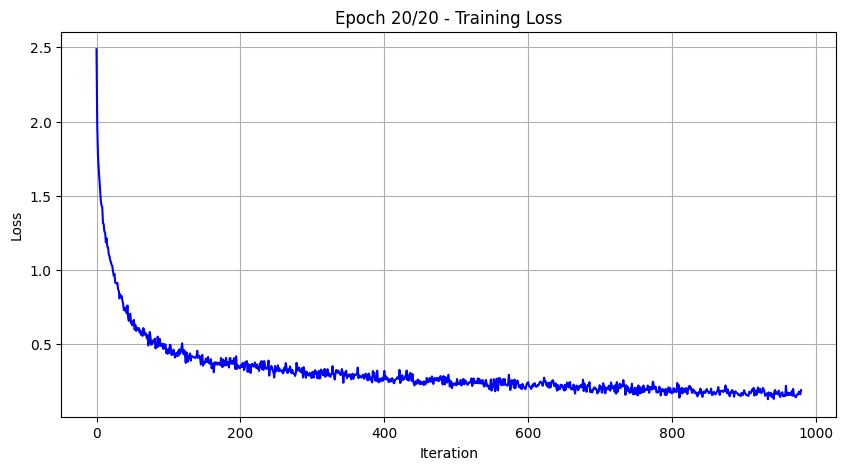

Epoch 20/20: Train Loss = 0.1882, Validation Loss = 0.4376
Validation Accuracy: 0.8590
Время обучения: 57.04 секунд
Test Accuracy: 85.63%


In [41]:
train_loss_history = []
val_loss_history = []
test_loss_history = []
test_accuracies_history = []
start_time = time.time()
n_epoch = 20
batch_size = 1024

for epoch in range(n_epoch):
    model.train()
    # === Обучение ===
    for batch_idx, (data, target) in enumerate(train_loader):
        # Прямой проход
        predictions = model(data)
        train_loss = criterion(predictions, target)

        # Обратный проход
        train_loss.backward()
        optimizer.step()

        # Сохраняем потери
        train_loss_history.append(train_loss.item())
        optimizer.zero_grad()

    # === Валидация ===
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)
        val_acc = (torch.argmax(val_outputs, dim=1) == torch.argmax(y_val, dim=1)).float().mean()
        val_loss_history.append(val_loss.item())

    # === Тестирование ===
    model.eval()
    with torch.no_grad():
        correct = 0
        total = 0
        for data, target in test_loader:
            predictions_test = model(data)
            test_loss = criterion(predictions_test, target)
            _, predicted = torch.max(predictions_test.data, 1)
            _, target_labels = torch.max(target, 1)
            total += target.size(0)
            correct += (predicted == target_labels).sum().item()

        test_loss_history.append(test_loss.item())
        accuracy = 100 * correct / total
        test_accuracies_history.append(accuracy)

    # === Визуализация ===
    display.clear_output(wait=True)
    plt.figure(figsize=(10, 5))

    plt.title(f"Epoch {epoch + 1}/{n_epoch} - Training Loss")
    plt.plot(train_loss_history, color="blue")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()

    print(f"Epoch {epoch + 1}/{n_epoch}: Train Loss = {train_loss.item():.4f}, Validation Loss = {val_loss.item():.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")
    end_time = time.time()  # Фиксируем конец
    elapsed_time = end_time - start_time  # Расчет времени обучения
    print(f"Время обучения: {elapsed_time:.2f} секунд")
    print(f"Test Accuracy: {accuracy:.2f}%")

model.eval()
with torch.no_grad():
    test_outputs = model(X_test)
    test_acc = (torch.argmax(test_outputs, dim=1) == torch.argmax(y_test, dim=1)).float().mean()
# print(f"Test Accuracy: {test_acc:.4f}")


Использование библиотеки PyTorch позволяет значительно и быстрее обучить модель (время обучение отличается в 20 раз), обнако показатель accuracy на тестовой выборке снизился (86%, а на аналогичной модели from scratch - 89%).